# Transformer Training for Sign Language Landmarks
This notebook trains a Transformer model on the pre-extracted facial/hand/pose landmarks.

In [26]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

## 1. Dataset Class
The landmark pipeline outputs `.npy` files containing temporal features.

In [27]:
class LandmarkDataset(Dataset):
    def __init__(self, data_dir, max_seq_len=15):
        self.data_dir = data_dir
        self.max_seq_len = max_seq_len
        self.file_paths = []
        self.labels = []
        
        # Get all subdirectories as classes
        self.classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
        self.label_encoder = LabelEncoder()
        self.label_encoder.fit(self.classes)
        
        # Save label encoder classes for inference later (Improvement #2)
        os.makedirs('../checkpoints', exist_ok=True)
        np.save('../checkpoints/label_classes.npy', self.label_encoder.classes_)
        
        for cls in self.classes:
            cls_dir = os.path.join(data_dir, cls)
            npy_files = glob.glob(os.path.join(cls_dir, "*.npy"))
            for f in npy_files:
                self.file_paths.append(f)
                self.labels.append(cls)
                
        self.encoded_labels = self.label_encoder.transform(self.labels)
        
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.encoded_labels[idx]
        
        # Load sequence of landmarks
        seq = np.load(file_path)
        seq = torch.tensor(seq, dtype=torch.float32)
        
        # We need to know actual sequence length for masked mean pooling
        actual_len = len(seq)
        if actual_len > self.max_seq_len:
            actual_len = self.max_seq_len
            
        # Padding or truncating to max_seq_len
        if len(seq) > self.max_seq_len:
            seq = seq[:self.max_seq_len]
        elif len(seq) < self.max_seq_len:
            pad_size = self.max_seq_len - len(seq)
            seq = torch.cat([seq, torch.zeros(pad_size, seq.size(1))])
            
        return seq, torch.tensor(label, dtype=torch.long), torch.tensor(actual_len, dtype=torch.long)

## 2. Transformer Model
We use a Transformer Encoder to process the sequence of landmarks and output a final classification.

In [28]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        # x shape: (seq_len, batch_size, d_model)
        x = x + self.pe[:x.size(0)]
        return x

class SignTransformer(nn.Module):
    def __init__(self, input_dim=168, num_classes=10, d_model=128, nhead=8, num_layers=4, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        # Project input feature dimension to d_model
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.fc_out = nn.Linear(d_model, num_classes)
        
    def forward(self, src, seq_lens):
        # src shape: (batch_size, seq_len, input_dim)
        x = self.input_projection(src)
        
        # Swap batch and seq_len for Positional Encoding
        x = x.transpose(0, 1)  # (seq_len, batch_size, d_model)
        x = self.pos_encoder(x)
        x = x.transpose(0, 1)  # (batch_size, seq_len, d_model)
        
        # We don't necessarily need src_key_padding_mask if doing properly masked pooling, 
        # but let's process through the encoder first
        output = self.transformer_encoder(x)
        
        # (Improvement #4) - Proper pooling ignoring padded features
        # Create a mask of shape (batch, seq_len, 1) where valid elements are 1
        batch_size, max_len, _ = output.size()
        mask = torch.arange(max_len)[None, :].to(output.device) < seq_lens[:, None]
        mask = mask.unsqueeze(-1).float()
        
        # Sum only the valid representations, then divide by actual sequence lengths
        sum_pooled = torch.sum(output * mask, dim=1)
        mean_pooled = sum_pooled / seq_lens.unsqueeze(-1).float()
        
        return self.fc_out(mean_pooled)

## 3. Training Setup

In [29]:
# Hyperparameters
DATA_DIR = '../outputs/landmarks'
BATCH_SIZE = 16
EPOCHS = 75
LEARNING_RATE = 1e-4
MAX_SEQ_LEN = 15 # Based on previous pipeline limits
INPUT_DIM = 168  # 56 landmarks * 3 coords
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Ensure Checkpoint Directory Exists (Improvement #3)
os.makedirs('../checkpoints', exist_ok=True)

dataset = LandmarkDataset(data_dir=DATA_DIR, max_seq_len=MAX_SEQ_LEN)
num_classes = len(dataset.classes)
print(f"Total samples: {len(dataset)}, Classes: {num_classes}")
print(f"Saved Label Encoder classes to '../checkpoints/label_classes.npy'")

# Split Dataset
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Initialize Model
model = SignTransformer(input_dim=INPUT_DIM, num_classes=num_classes).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Add Learning Rate Scheduler (Improvement #5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

print("Model Initialized on:", DEVICE)

Total samples: 187, Classes: 15
Saved Label Encoder classes to '../checkpoints/label_classes.npy'
Model Initialized on: cuda


h:\Projects\sem-5-ml-project\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 4. Training Loop

Epoch [1/75] | Train Loss: 2.7291 | Train Acc: 10.07% | Val Loss: 2.7181 | Val Acc: 5.26%
 -> Saved new best model!
Epoch [2/75] | Train Loss: 2.5677 | Train Acc: 14.77% | Val Loss: 2.6827 | Val Acc: 2.63%
 -> Saved new best model!
Epoch [3/75] | Train Loss: 2.4119 | Train Acc: 21.48% | Val Loss: 2.5676 | Val Acc: 5.26%
 -> Saved new best model!
Epoch [4/75] | Train Loss: 2.2646 | Train Acc: 29.53% | Val Loss: 2.4771 | Val Acc: 13.16%
 -> Saved new best model!
Epoch [5/75] | Train Loss: 2.1748 | Train Acc: 33.56% | Val Loss: 2.3604 | Val Acc: 21.05%
 -> Saved new best model!
Epoch [6/75] | Train Loss: 2.0588 | Train Acc: 40.27% | Val Loss: 2.2581 | Val Acc: 28.95%
 -> Saved new best model!
Epoch [7/75] | Train Loss: 1.9356 | Train Acc: 46.31% | Val Loss: 2.1760 | Val Acc: 39.47%
 -> Saved new best model!
Epoch [8/75] | Train Loss: 1.7840 | Train Acc: 55.03% | Val Loss: 2.1368 | Val Acc: 34.21%
 -> Saved new best model!
Epoch [9/75] | Train Loss: 1.7222 | Train Acc: 55.03% | Val Loss: 2

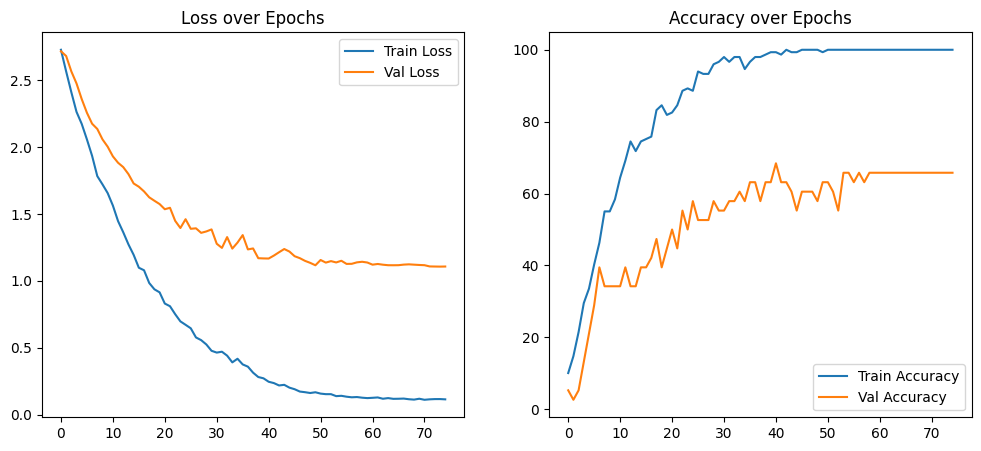

In [30]:
import matplotlib.pyplot as plt

best_val_loss = float('inf')

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    # Notice we unpack 3 elements now (data, target, seq_len)
    for batch_idx, (data, target, seq_len) in enumerate(train_loader):
        data, target, seq_len = data.to(DEVICE), target.to(DEVICE), seq_len.to(DEVICE)
        
        optimizer.zero_grad()
        output = model(data, seq_len)
        loss = criterion(output, target)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
        
    train_acc = 100 * correct / total
    avg_train_loss = total_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data, target, seq_len in val_loader:
            data, target, seq_len = data.to(DEVICE), target.to(DEVICE), seq_len.to(DEVICE)
            output = model(data, seq_len)
            loss = criterion(output, target)
            val_loss += loss.item()
            
            _, predicted = torch.max(output.data, 1)
            val_total += target.size(0)
            val_correct += (predicted == target).sum().item()
            
    val_acc = 100 * val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)
    
    # Step the scheduler based on validation loss
    scheduler.step(avg_val_loss)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f'Epoch [{epoch+1}/{EPOCHS}] | '
          f'Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%')

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        # Improvement 3: Directory was created in the setup cell above securely
        torch.save(model.state_dict(), '../checkpoints/transformer_best.pth')
        print(" -> Saved new best model!")

# Improvement 5: Plotting the results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()